# 04 — Decision Tree Interpretability
Visualise the tree structure, extract feature importances, and read the decision rules.

In [1]:
import sys
sys.path.insert(0, '..')

from src.data import load_data, split_data
from src.models import train_decision_tree
from src.interpret_tree import feature_importances, plot_tree, plot_feature_importances

In [2]:
X, y = load_data('../data/heart_failure_clinical_records_dataset.csv')
X_train, X_test, y_train, y_test = split_data(X, y)

# Decision Tree is trained on raw features so split thresholds are human-readable
dt = train_decision_tree(X_train, y_train)

FEATURE_NAMES = list(X.columns)
CLASS_NAMES = ['survived', 'deceased']

## Tree Diagram
Each node shows the split condition, the Gini impurity, the sample count, and the class distribution.
Colour intensity reflects class purity — darker means more confident.

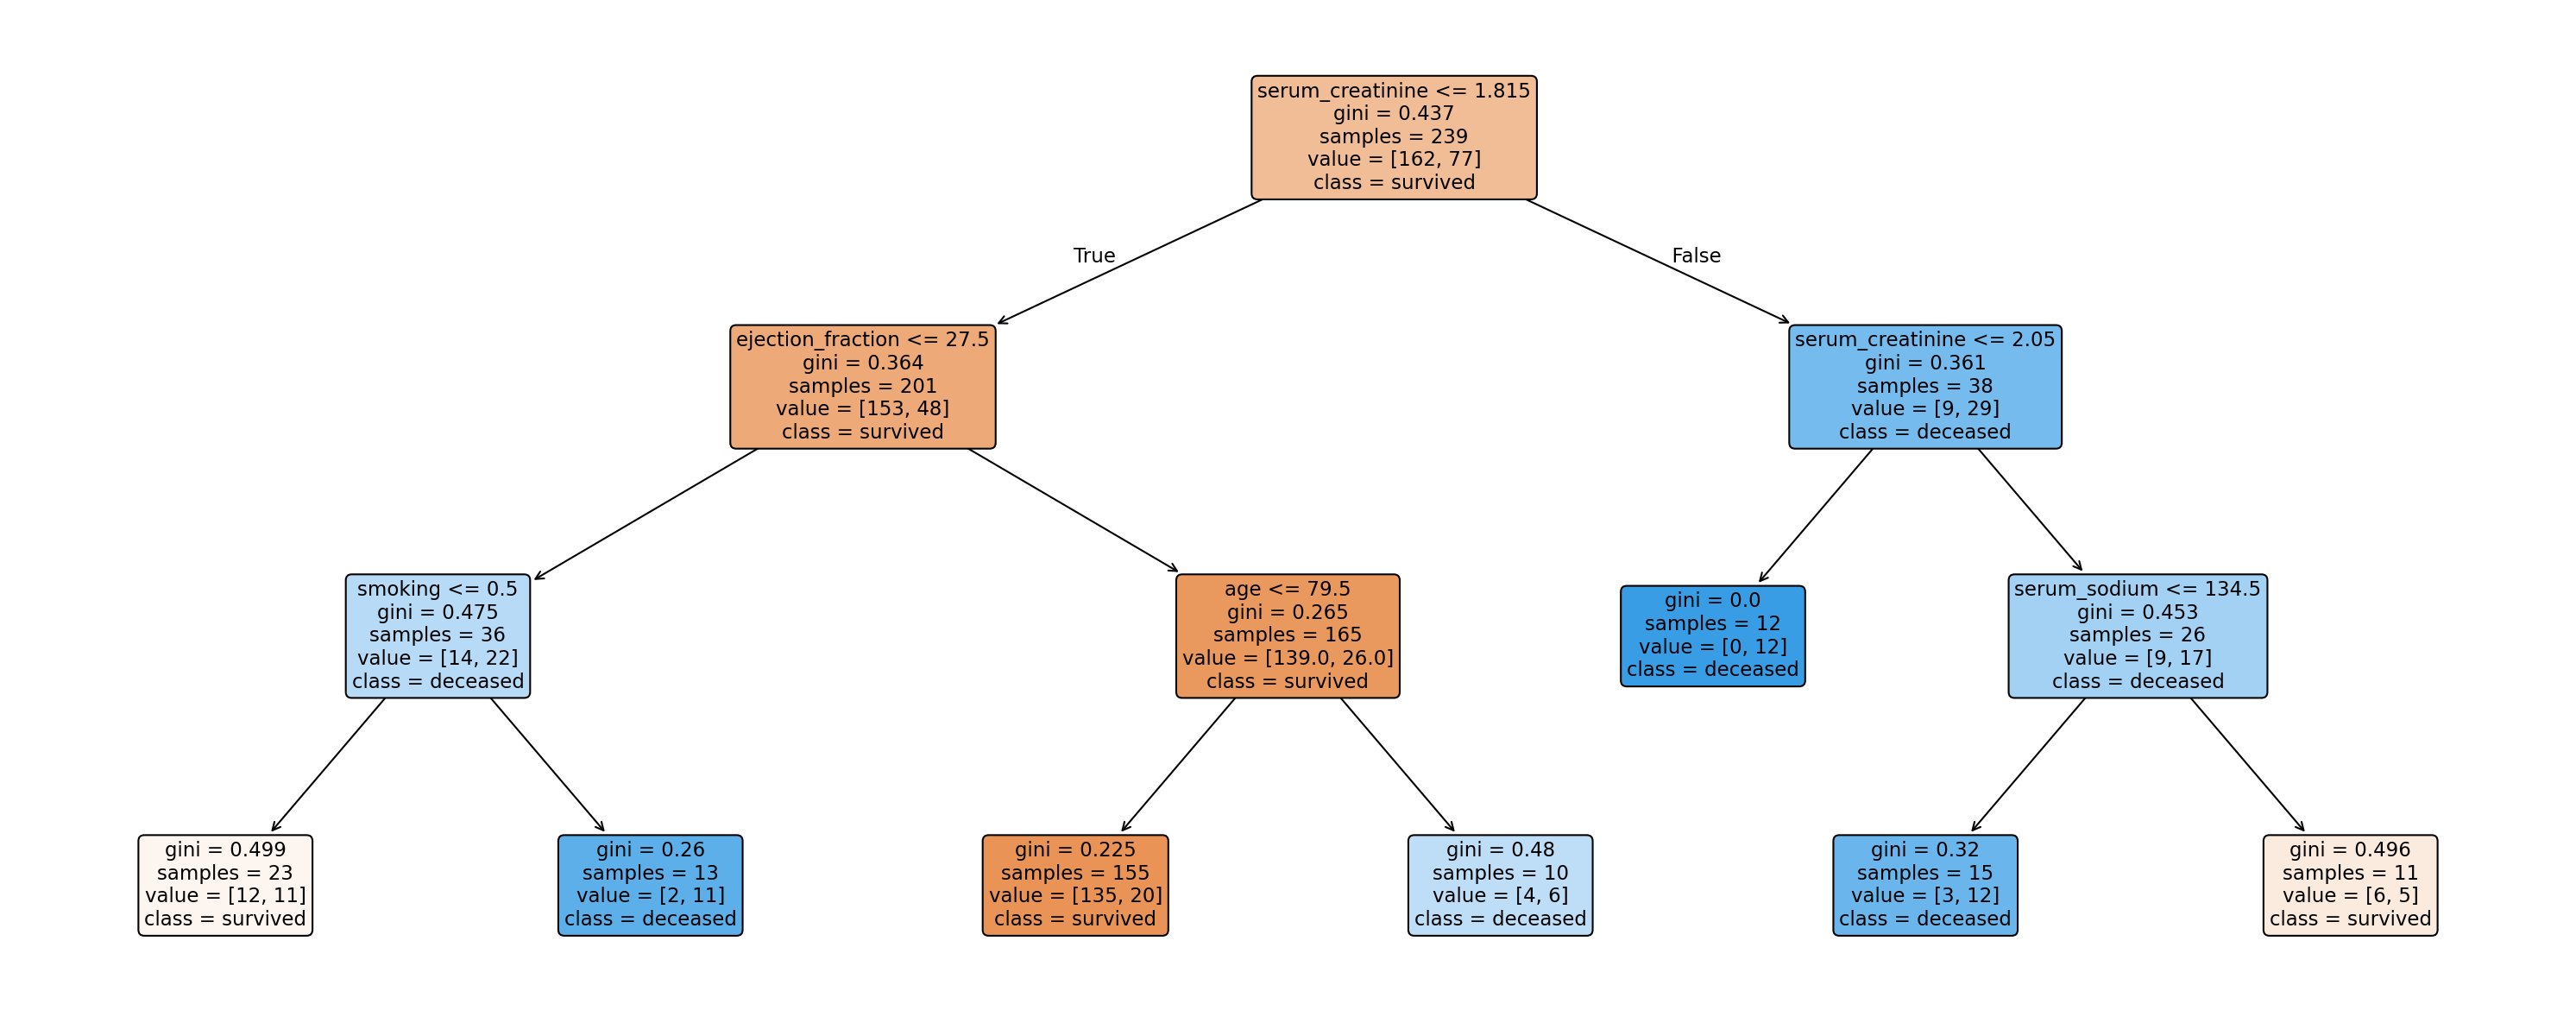

In [3]:
plot_tree(dt, FEATURE_NAMES, CLASS_NAMES, path='../outputs/tree_plot.png')

from IPython.display import Image
Image('../outputs/tree_plot.png')

## Feature Importances
Built-in impurity-based importances: the total reduction in Gini impurity each feature contributes across all splits, normalised to sum to 1.

In [4]:
imp_df = feature_importances(dt, FEATURE_NAMES)
imp_df

,feature,importance
0,serum_creatinine,0.493103
1,ejection_fraction,0.306783
2,age,0.105160
3,smoking,0.056732
4,serum_sodium,0.038222
5,creatinine_phosphokinase,0.000000
6,anaemia,0.000000
7,platelets,0.000000
8,high_blood_pressure,0.000000
9,diabetes,0.000000


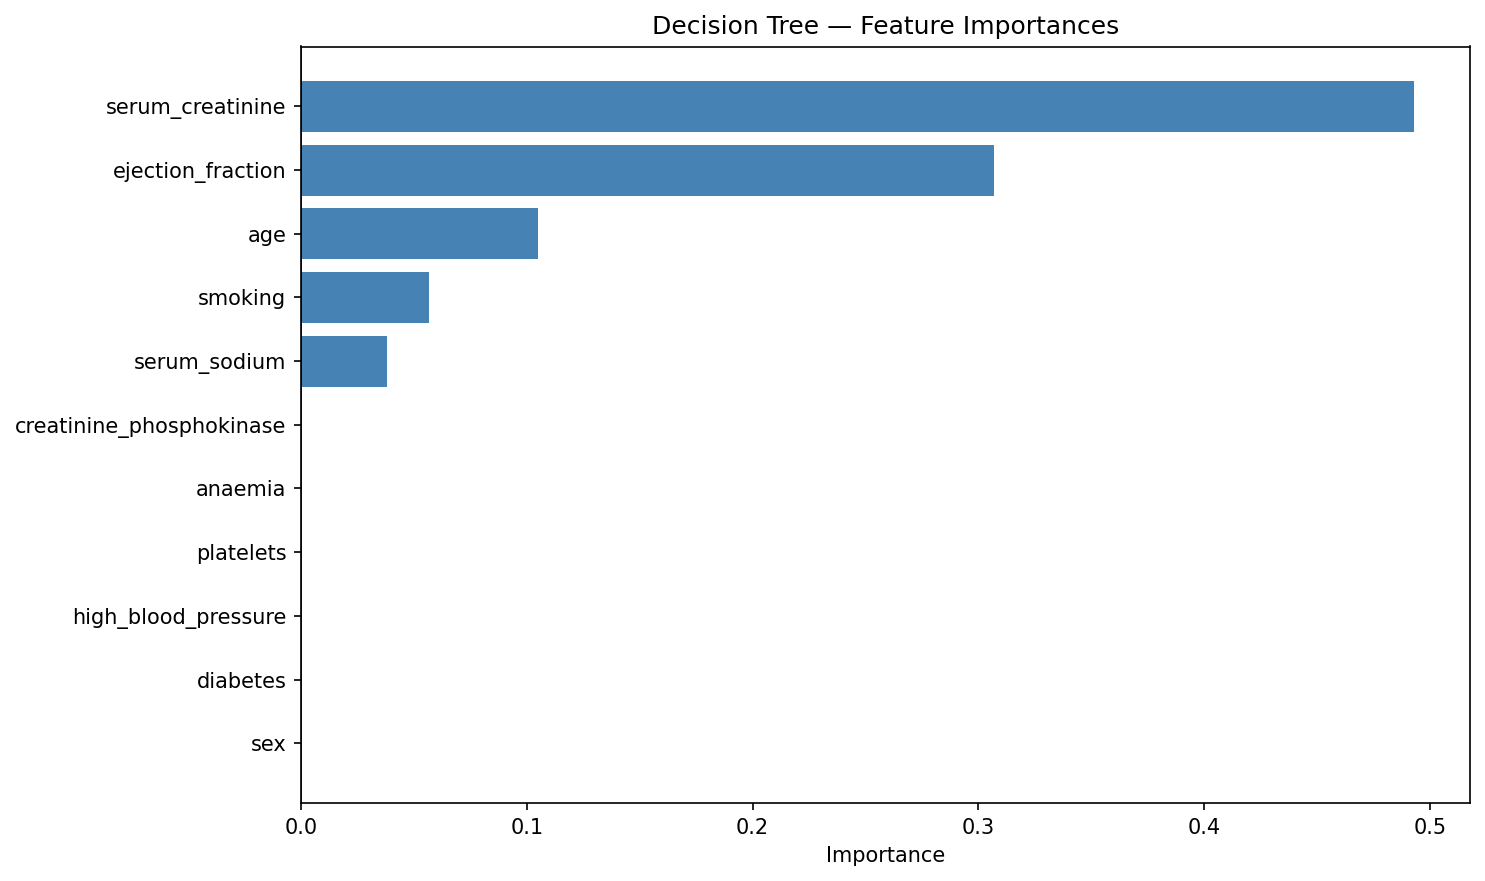

In [5]:
plot_feature_importances(imp_df, path='../outputs/feature_importances_tree.png')

from IPython.display import Image
Image('../outputs/feature_importances_tree.png')

## Reading the Decision Rules
The tree with `max_depth=3` and `min_samples_leaf=10` produces at most 8 leaves.
The dominant splits and what they mean clinically:

In [6]:
from sklearn.tree import export_text

rules = export_text(dt, feature_names=FEATURE_NAMES)
print(rules)

|--- serum_creatinine <= 1.81
|   |--- ejection_fraction <= 27.50
|   |   |--- smoking <= 0.50
|   |   |   |--- class: 0
|   |   |--- smoking >  0.50
|   |   |   |--- class: 1
|   |--- ejection_fraction >  27.50
|   |   |--- age <= 79.50
|   |   |   |--- class: 0
|   |   |--- age >  79.50
|   |   |   |--- class: 1
|--- serum_creatinine >  1.81
|   |--- serum_creatinine <= 2.05
|   |   |--- class: 1
|   |--- serum_creatinine >  2.05
|   |   |--- serum_sodium <= 134.50
|   |   |   |--- class: 1
|   |   |--- serum_sodium >  134.50
|   |   |   |--- class: 0



## Observations

- Features with zero importance were never used for any split — they have no discriminative power at this depth.
- The root split (first question) is the single most informative feature for survival prediction.
- `time` (follow-up period) often dominates because patients who survive long enough to be followed up are already self-selected — worth noting as a potential data leakage concern.
- `ejection_fraction` and `serum_creatinine` are the two primary clinical markers, consistent with cardiology literature.